In [2]:
# Damit Pfadobjekte erzeugt werden
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [4]:
pfad_rohdaten = Path("../data/raw")
print(pfad_rohdaten.resolve()) #zeigt vollständigen Pfad an

/Users/koppanymolnar/Documents/Projekt-Timeseries/industrial-ai-timeseries/data/raw


In [5]:
# Druckwerte in Bar

ps1 = pd.read_csv(
    pfad_rohdaten / "PS1.txt",
    sep = r"\s+", # Separator, mehrere Leerzeichen
    header = None,
)

# Temperaturwerte in Grad Celsius

ts1 = pd.read_csv(
    pfad_rohdaten / "TS1.txt",
    sep = r"\s+",
    header = None,
)

# Volumenstrom in Litern pro Minute

fs1 = pd.read_csv(
    pfad_rohdaten / "FS1.txt",
    sep = r"\s+",
    header = None,
)

# Vibrationsgeschwindigkeit in Millimetern pro Sekunde

vs1 = pd.read_csv(
    pfad_rohdaten / "VS1.txt",
    sep = r"\s+",
    header = None,
)

# Zustandsklassen

profile = pd.read_csv(
    pfad_rohdaten / "profile.txt",
    sep = r"\s+",
    header = None,
)

##### Zeilen <=> Maschinenzyklen
##### Spalten <=> Werte innerhalb eines Maschinenzyklus

In [6]:
print("PS1: ", ps1.shape)
print("TS1: ", ts1.shape)
print("FS1: ", fs1.shape)
print("VS1: ", vs1.shape)
print("Profile: ", profile.shape)

PS1:  (2205, 6000)
TS1:  (2205, 60)
FS1:  (2205, 600)
VS1:  (2205, 60)
Profile:  (2205, 5)


In [7]:
profile.columns = [
    "cooler_condition",
    "valve_condition",
    "internal_pump_leakage",
    "hydraulic_accumulator",
    "stable_flag",
]

profile.head()

,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


##### Das sind die Zustände für die 2205 Zyklen, die Labels für jeden Maschinenzyklus.

##### cooler_condition beschreibt die Leistungsfähigkeit des Kühlers. 3 <=> nahezu vollständiger Ausfall, 20 <=> verringerte Kühlleistung und 100 <=> volle Kühlleistung.

##### valve_condiditon beschreibt das Schaltverhalten des Ventils. 73 <=> nahezu vollständiger Ausfall, 80 <=> starke Verzögerung, 90 <=> geringe Verzögerung und 100 <=> optimales Schaltverhalten.

##### internal_pump_leakage beschreibt die Stärke einer internen Leckage in der Pumpe. 0 <=> keine Leckage, 1 <=> geringe Leckage und 2 <=> starke Leckage.

##### hydraulic_accumulator beschreibt den Gasvordruck des Hydraulikspeichers in bar. 90 <=> stark verringerter Druck, 100 <=> deutlich verringerter Druck, 115 <=> leicht verringerter Druck und 130 <=> optimaler Druck.

##### stable_flag beschreibt ob der Maschinenzyklus unter stabilen Bedingungen aufgenommen wurde. 0 <=> ,,Bedingungen waren stabil." und 1 <=> ,,Stabiler Zustand wurde möglicherweise noch nicht erreicht."


##### Wir haben für jeden Zyklus die Sensordaten PS1, TS1, FS1 und VS1. Wir haben zusätzlich aber auch für jeden Zyklus die Zustände der Maschine (profile) wie cooler_condition usw.

## EDA:

In [8]:
profile["cooler_condition"].value_counts().sort_index()

cooler_condition
3      732
20     732
100    741
Name: count, dtype: int64

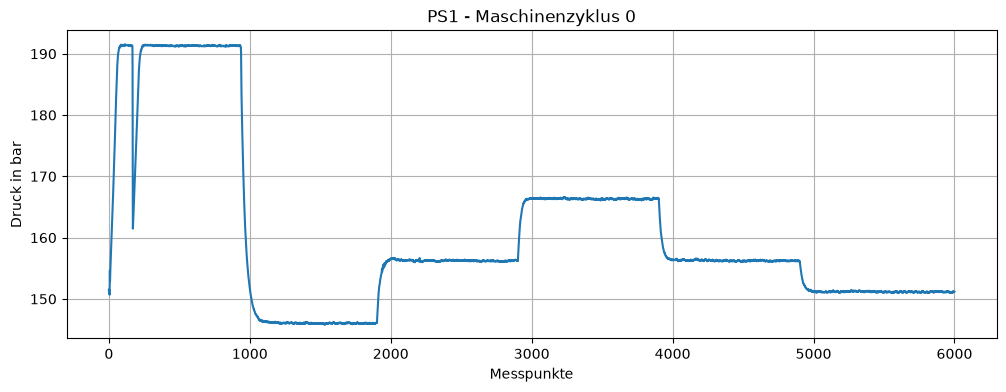

In [9]:
i = 0

plt.figure(figsize = (12,4))
plt.plot(ps1.iloc[i].to_numpy())
plt.xlabel("Messpunkte")
plt.ylabel("Druck in bar")
plt.title(f"PS1 - Maschinenzyklus {i}")
plt.grid()
plt.show()

In [10]:
cooler3ListeIndizes = profile.index[profile["cooler_condition"] == 3].to_list()
print(cooler3ListeIndizes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

##### Vergleichsplot erstellen:

In [11]:
cooler3First = profile.index[profile["cooler_condition"] == 3][0]
cooler20First = profile.index[profile["cooler_condition"] == 20][0]
cooler100First = profile.index[profile["cooler_condition"] == 100][0]

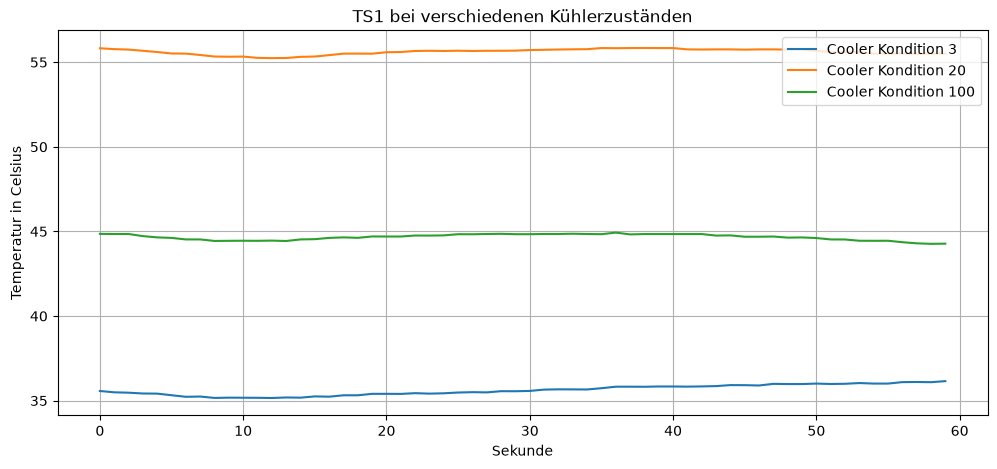

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    ts1.iloc[cooler3First].to_numpy(),
    label = "Cooler Kondition 3"
)

plt.plot(
    ts1.iloc[cooler20First].to_numpy(),
    label = "Cooler Kondition 20"
)

plt.plot(
    ts1.iloc[cooler100First].to_numpy(),
    label = "Cooler Kondition 100"
)

plt.xlabel("Sekunde")
plt.ylabel("Temperatur in Celsius")
plt.title("TS1 bei verschiedenen Kühlerzuständen")
plt.legend()
plt.grid()
plt.show()

In [13]:
cooler3Liste = profile.index[profile["cooler_condition"] == 3].to_list()
cooler20Liste = profile.index[profile["cooler_condition"] == 20].to_list()
cooler100Liste = profile.index[profile["cooler_condition"] == 100].to_list()

In [14]:
ts1Cooler3DF = ts1.iloc[cooler3Liste]
# print(ts1Cooler3.to_string())

In [15]:
ts1Cooler20DF = ts1.iloc[cooler20Liste]
ts1Cooler100DF = ts1.iloc[cooler100Liste]

##### Holen jetzt die Durchschnittswerte der Features aus den 3 DataFrames (60 Werte jeweils):

In [16]:
ts1Mean3Sek = ts1Cooler3DF.mean(axis = 0) # spaltenweise, Durchschnitt über alle Zyklen pro Sekunde
ts1Mean20Sek = ts1Cooler20DF.mean(axis = 0)
ts1Mean100Sek = ts1Cooler100DF.mean(axis = 0)

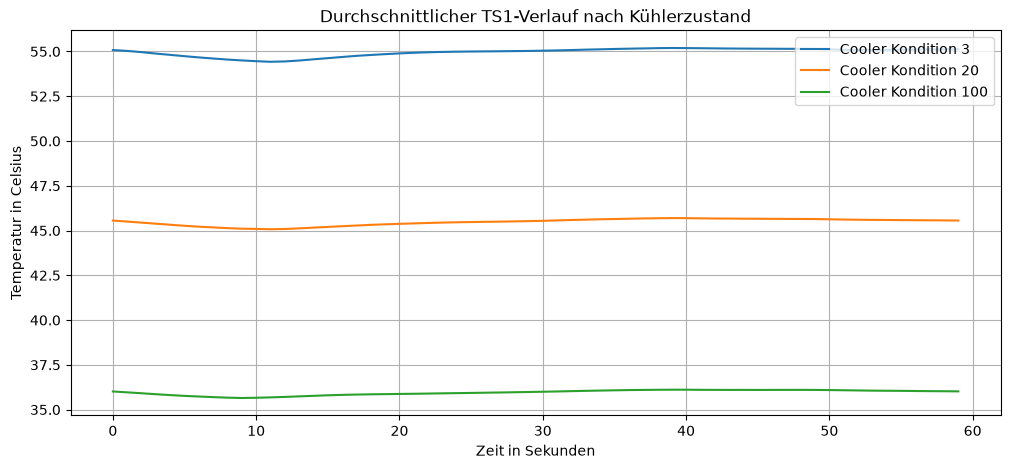

In [17]:
plt.figure(figsize = (12, 5))

plt.plot(
    ts1Mean3Sek.to_numpy(),
    label = "Cooler Kondition 3"
)

plt.plot(
    ts1Mean20Sek.to_numpy(),
    label = "Cooler Kondition 20"
)

plt.plot(
    ts1Mean100Sek.to_numpy(),
    label = "Cooler Kondition 100"
)

plt.xlabel("Zeit in Sekunden")
plt.ylabel("Temperatur in Celsius")
plt.title("Durchschnittlicher TS1-Verlauf nach Kühlerzustand")
plt.legend()
plt.grid()
plt.show()

In [18]:
ts1Mean3Zyklus = ts1Cooler3DF.mean(axis = 1) # Zeilenweise, Durschnittswert bei einem Zyklus jeweils
ts1Mean20Zyklus = ts1Cooler20DF.mean(axis = 1)
ts1Mean100Zyklus = ts1Cooler100DF.mean(axis = 1)

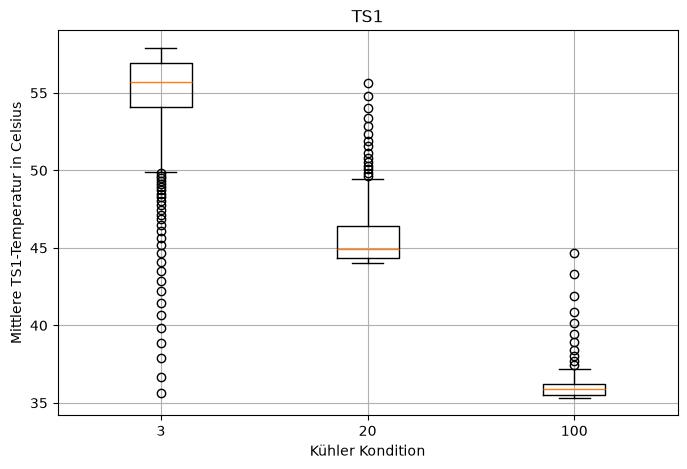

In [19]:
plt.figure(figsize = (8, 5))

plt.boxplot(
    [
        ts1Mean3Zyklus,
        ts1Mean20Zyklus,
        ts1Mean100Zyklus
    ],

    tick_labels = ["3", "20", "100"]
)

plt.xlabel("Kühler Kondition")
plt.ylabel("Mittlere TS1-Temperatur in Celsius")
plt.title("TS1")
plt.grid()
plt.show()

##### Je schlechter die Kühlleistung, desto höher ist sind die Temperaturen.

##### Hängen auch andere Sensorwerte mit der Kühlleistung zusammen?

##### Bei PS1, beeinflusst der Kühlerzustand den Druck?

In [20]:
# DataFrames:

ps1Cooler3DF = ps1.iloc[cooler3Liste]
ps1Cooler20DF = ps1.iloc[cooler20Liste]
ps1Cooler100DF = ps1.iloc[cooler100Liste]

# Nur pro Zyklus:

ps1Cooler3Mean = ps1Cooler3DF.mean(axis = 1)
ps1Cooler20Mean = ps1Cooler20DF.mean(axis = 1)
ps1Cooler100Mean = ps1Cooler100DF.mean(axis = 1)


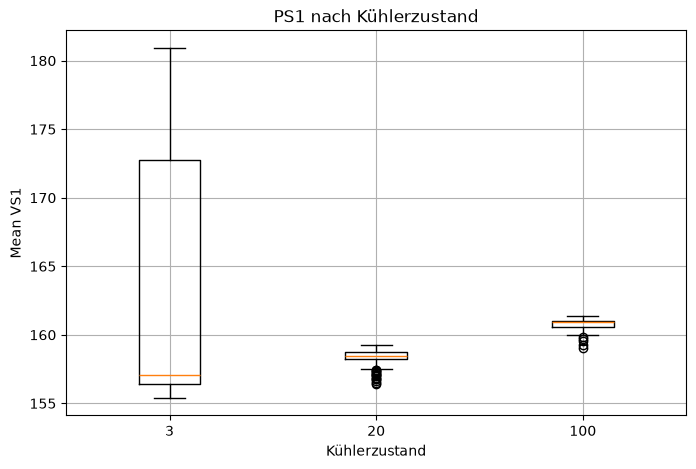

In [21]:
plt.figure(figsize = (8, 5))

plt.boxplot(
    [
        ps1Cooler3Mean,
        ps1Cooler20Mean,
        ps1Cooler100Mean
    ],
    
    tick_labels = ["3", "20", "100"]
)

plt.xlabel("Kühlerzustand")
plt.ylabel("Mean VS1")
plt.title("PS1 nach Kühlerzustand")
plt.grid()
plt.show()

##### Feature wie min und max eventuell nützlich.

##### Diesmal der zeitliche Verlauf von FS1:

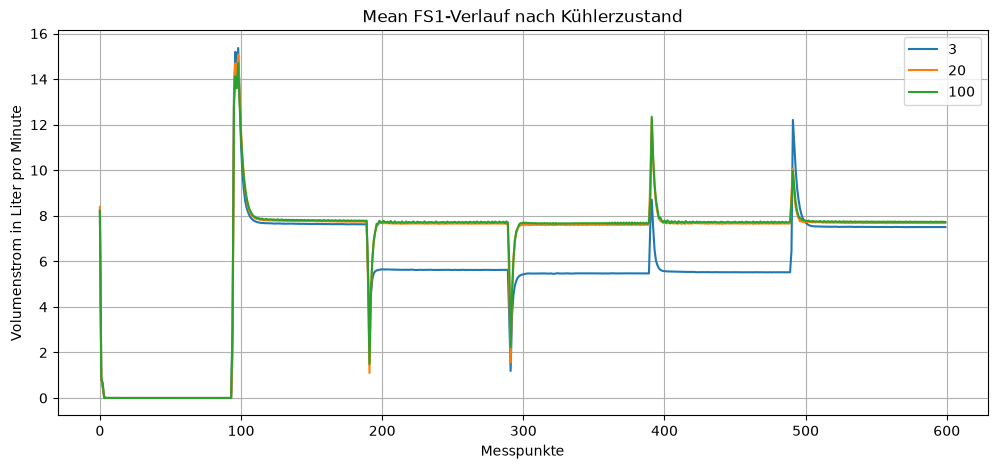

In [22]:
fs1Cooler3DF = fs1.iloc[cooler3Liste]
fs1Cooler20DF = fs1.iloc[cooler20Liste]
fs1Cooler100DF = fs1.iloc[cooler100Liste]

fs1Mean3 = fs1Cooler3DF.mean(axis = 0)
fs1Mean20 = fs1Cooler20DF.mean(axis = 0)
fs1Mean100 = fs1Cooler100DF.mean(axis = 0)

plt.figure(figsize = (12, 5))

plt.plot(
    fs1Mean3.to_numpy(),
    label = "3"
)

plt.plot(
    fs1Mean20.to_numpy(),
    label = "20"
)

plt.plot(
    fs1Mean100.to_numpy(),
    label = "100"
)

plt.xlabel("Messpunkte")
plt.ylabel("Volumenstrom in Liter pro Minute")
plt.title("Mean FS1-Verlauf nach Kühlerzustand")
plt.legend()
plt.grid()
plt.show()

##### Bereich 200 bis fast 500 interessant.

##### Boxplot:

In [23]:
fs1Mean3B = fs1Cooler3DF.mean(axis = 1)
fs1Mean20B = fs1Cooler20DF.mean(axis = 1)
fs1Mean100B = fs1Cooler100DF.mean(axis = 1)

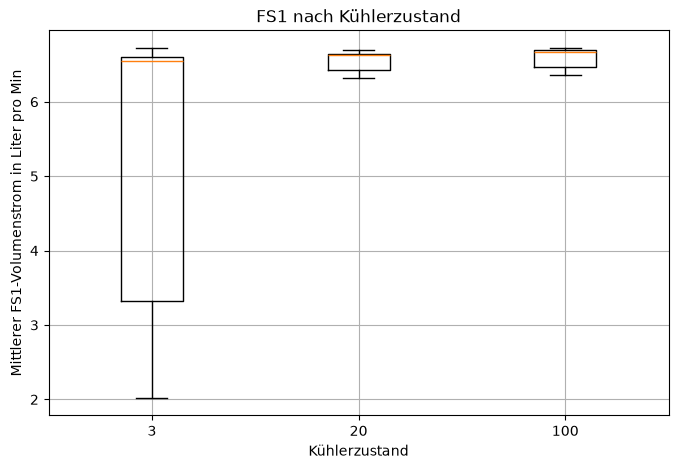

In [24]:
plt.figure(figsize = (8, 5))

plt.boxplot(
    [
        fs1Mean3B,
        fs1Mean20B,
        fs1Mean100B
    ],

    tick_labels = ["3", "20", "100"]
    
)

plt.xlabel("Kühlerzustand")
plt.ylabel("Mittlerer FS1-Volumenstrom in Liter pro Min")
plt.title("FS1 nach Kühlerzustand")
plt.grid()
plt.show()

##### VS1:

In [25]:
vs1Cooler3DF = vs1.iloc[cooler3Liste]
vs1Cooler20DF = vs1.iloc[cooler20Liste]
vs1Cooler100DF = vs1.iloc[cooler100Liste]

vs1Mean3Zyklus = vs1Cooler3DF.mean(axis = 1)
vs1Mean20Zyklus = vs1Cooler20DF.mean(axis = 1)
vs1Mean100Zyklus = vs1Cooler100DF.mean(axis = 1)

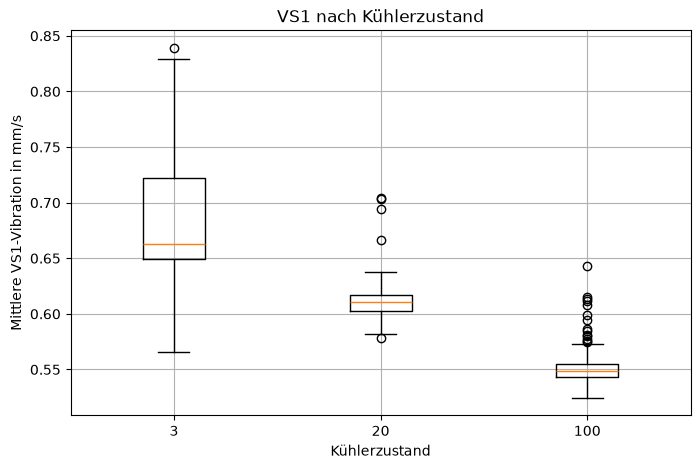

In [26]:
plt.figure(figsize = (8, 5))

plt.boxplot(
    [
        vs1Mean3Zyklus,
        vs1Mean20Zyklus,
        vs1Mean100Zyklus
    ],
    tick_labels=["3", "20", "100"]
)

plt.xlabel("Kühlerzustand")
plt.ylabel("Mittlere VS1-Vibration in mm/s")
plt.title("VS1 nach Kühlerzustand")
plt.grid()
plt.show()

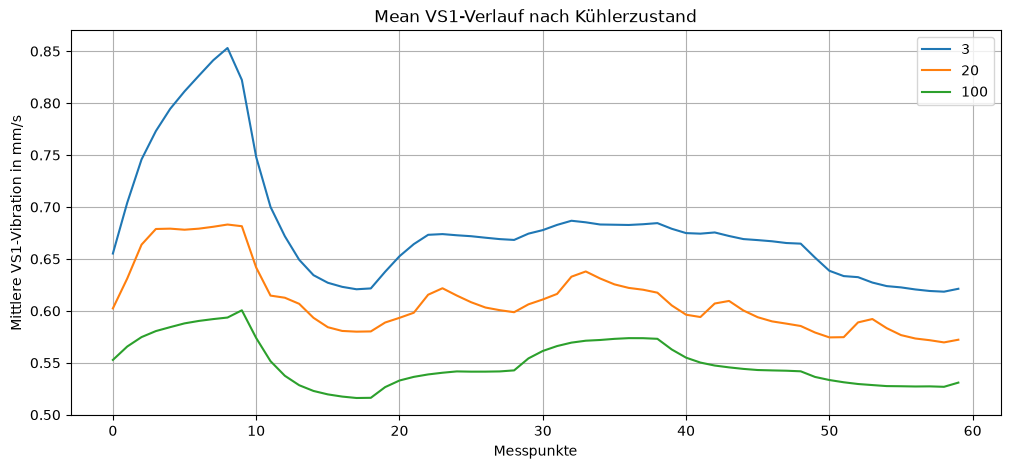

In [27]:
vs1Mean3Verlauf = vs1Cooler3DF.mean(axis = 0)
vs1Mean20Verlauf = vs1Cooler20DF.mean(axis = 0)
vs1Mean100Verlauf = vs1Cooler100DF.mean(axis = 0)

plt.figure(figsize = (12, 5))

plt.plot(
    vs1Mean3Verlauf.to_numpy(),
    label = "3"
)

plt.plot(
    vs1Mean20Verlauf.to_numpy(),
    label = "20"
)

plt.plot(
    vs1Mean100Verlauf.to_numpy(),
    label = "100"
)

plt.xlabel("Messpunkte")
plt.ylabel("Mittlere VS1-Vibration in mm/s")
plt.title("Mean VS1-Verlauf nach Kühlerzustand")
plt.legend()
plt.grid()
plt.show()

##### Aussagekräftig, klare Unterschiede.

## Feature Engineering:

In [28]:
print(ps1.shape)
print(ts1.shape)
print(fs1.shape)
print(vs1.shape)

(2205, 6000)
(2205, 60)
(2205, 600)
(2205, 60)


In [29]:
features = pd.DataFrame(
    {
        "ps1Mean": ps1.mean(axis = 1),
        "ps1Std": ps1.std(axis = 1),
        "ps1Min": ps1.min(axis = 1),
        "ps1Max": ps1.max(axis = 1),
        "ps1Median": ps1.median(axis = 1),
        "ps1Range": ps1.max(axis = 1) - ps1.min(axis = 1),

        "ts1Mean": ts1.mean(axis = 1),
        "ts1Std": ts1.std(axis = 1),
        "ts1Min": ts1.min(axis = 1),
        "ts1Max": ts1.max(axis = 1),
        "ts1Median": ts1.median(axis = 1),
        "ts1Range": ts1.max(axis = 1) - ts1.min(axis = 1),

        "fs1Mean": fs1.mean(axis = 1),
        "fs1Std": fs1.std(axis = 1),
        "fs1Min": fs1.min(axis = 1),
        "fs1Max": fs1.max(axis = 1),
        "fs1Median": fs1.median(axis = 1),
        "fs1Range": fs1.max(axis = 1) - fs1.min(axis = 1),

        "vs1Mean": vs1.mean(axis = 1),
        "vs1Std": vs1.std(axis = 1),
        "vs1Min": vs1.min(axis = 1),
        "vs1Max": vs1.max(axis = 1),
        "vs1Median": vs1.median(axis = 1),
        "vs1Range": vs1.max(axis = 1) - vs1.min(axis = 1),
    }
)

##### 4 Sensoren x 6 Kennzahlen = 24 Features

In [30]:
features.shape

(2205, 24)

In [31]:
display(features[0:5])

,ps1Mean,ps1Std,ps1Min,ps1Max,ps1Median,ps1Range,ts1Mean,ts1Std,ts1Min,ts1Max,ts1Median,ts1Range,fs1Mean,fs1Std,fs1Min,fs1Max,fs1Median,fs1Range,vs1Mean,vs1Std,vs1Min,vs1Max,vs1Median,vs1Range
0,160.673492,13.939309,145.83,191.51,156.25,45.68,35.621983,0.308230,35.156,36.152,35.5720,0.996,6.709815,3.015428,0.0,18.710,7.836,18.710,0.576950,0.027078,0.532,0.624,0.5770,0.092
1,160.603320,14.118967,145.73,191.47,156.06,45.74,36.676967,0.585740,35.648,37.488,36.7675,1.840,6.715315,3.006248,0.0,18.712,7.853,18.712,0.565850,0.027241,0.524,0.626,0.5595,0.102
2,160.347720,14.192619,145.37,191.41,155.72,46.04,37.880800,0.559169,36.879,38.621,38.0235,1.742,6.718522,3.014248,0.0,18.698,7.847,18.698,0.576533,0.036729,0.529,0.662,0.5620,0.133
3,160.188088,14.227803,145.14,191.34,155.56,46.20,38.879050,0.516176,37.887,39.473,39.0550,1.586,6.720565,3.020176,0.0,18.896,7.843,18.896,0.569267,0.033464,0.527,0.645,0.5550,0.118
4,160.000472,14.276434,144.95,191.41,155.34,46.46,39.803917,0.535374,38.789,40.391,39.9670,1.602,6.690308,3.011550,0.0,18.876,7.831,18.876,0.577367,0.033484,0.524,0.660,0.5760,0.136


In [32]:
features.isna().sum()

ps1Mean      0
ps1Std       0
ps1Min       0
ps1Max       0
ps1Median    0
ps1Range     0
ts1Mean      0
ts1Std       0
ts1Min       0
ts1Max       0
ts1Median    0
ts1Range     0
fs1Mean      0
fs1Std       0
fs1Min       0
fs1Max       0
fs1Median    0
fs1Range     0
vs1Mean      0
vs1Std       0
vs1Min       0
vs1Max       0
vs1Median    0
vs1Range     0
dtype: int64

In [33]:
labeledDataFrame = features.copy()
labeledDataFrame["cooler_condition"] = profile["cooler_condition"]
display(labeledDataFrame[0:5])

,ps1Mean,ps1Std,ps1Min,ps1Max,ps1Median,ps1Range,ts1Mean,ts1Std,ts1Min,ts1Max,ts1Median,ts1Range,fs1Mean,fs1Std,fs1Min,fs1Max,fs1Median,fs1Range,vs1Mean,vs1Std,vs1Min,vs1Max,vs1Median,vs1Range,cooler_condition
0,160.673492,13.939309,145.83,191.51,156.25,45.68,35.621983,0.308230,35.156,36.152,35.5720,0.996,6.709815,3.015428,0.0,18.710,7.836,18.710,0.576950,0.027078,0.532,0.624,0.5770,0.092,3
1,160.603320,14.118967,145.73,191.47,156.06,45.74,36.676967,0.585740,35.648,37.488,36.7675,1.840,6.715315,3.006248,0.0,18.712,7.853,18.712,0.565850,0.027241,0.524,0.626,0.5595,0.102,3
2,160.347720,14.192619,145.37,191.41,155.72,46.04,37.880800,0.559169,36.879,38.621,38.0235,1.742,6.718522,3.014248,0.0,18.698,7.847,18.698,0.576533,0.036729,0.529,0.662,0.5620,0.133,3
3,160.188088,14.227803,145.14,191.34,155.56,46.20,38.879050,0.516176,37.887,39.473,39.0550,1.586,6.720565,3.020176,0.0,18.896,7.843,18.896,0.569267,0.033464,0.527,0.645,0.5550,0.118,3
4,160.000472,14.276434,144.95,191.41,155.34,46.46,39.803917,0.535374,38.789,40.391,39.9670,1.602,6.690308,3.011550,0.0,18.876,7.831,18.876,0.577367,0.033484,0.524,0.660,0.5760,0.136,3


In [34]:
labeledDataFrame.shape

(2205, 25)

In [35]:
X = labeledDataFrame.drop(columns = ["cooler_condition"])
y = labeledDataFrame["cooler_condition"]

print(X.shape)
print(y.shape) # 1D

(2205, 24)
(2205,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1764, 24)
(441, 24)
(1764,)
(441,)


## Modelle trainieren:

In [38]:
modell = RandomForestClassifier(
    random_state = 42
)

modell.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [42]:
y_pred = modell.predict(X_test) # Einzelne Vorhersagen aus den Testdaten z.B. [3, 3, 3, 20, 20, 100, ...]
print(accuracy_score(y_test, y_pred)) # Vergleich echten Labels mit vorhergesagten Labels

testAccuracy = modell.score(X_test, y_test) # das gleiche wie oben, nur kompakter
print(testAccuracy)

trainAccuracy = modell.score(X_train, y_train) # Wegen Overfitting zum Vergleichen prüfen
print(trainAccuracy)

0.9977324263038548
0.9977324263038548
1.0
